# Transaction Categorization pipeline (TF-IDF + Random Forest)

This notebook trains a machine learning model to automatically categorize short transaction descriptions (e.g., "spent 4k on fuel").

It follows a robust Data Science pipeline:
1. **Data Loading & Generation (w/ Outliers)**
2. **Exploratory Data Analysis (EDA)**
3. **Data Cleaning & Text Preprocessing**
4. **Model Training (TF-IDF + Random Forest + GridSearchCV)**
5. **Evaluation & Confusion Matrix**
6. **Real-World API Test (Simulation)**

In [1]:
!pip install -q scikit-learn pandas numpy joblib matplotlib seaborn nltk

## 1. Data Generation (With Outliers & Noise)
We generate synthetic transaction data with **Uganda-heavy** vocabulary (mobile money, UMEME/NWSC, local brands, transport, schools) and **unified `Food`** labels (lunch, dinner, eating out, dining, street food, etc.). **Income** covers salary and wages, gifts and donations received, business profit, investment returns (dividends, interest, unit trusts), refunds, and student-related inflows (upkeep, pocket money, allowance, bursary, scholarship, stipend). **Entertainment** includes pay-TV names (DStv, StarTimes, Zuku, GOtv, Azam, Showmax) and similar services. A second pass adds **receipt-style** lines (mall/supermarket → Shopping; hospital/pharmacy → Healthcare; bank slips → Banking & Finance; salary/credits → Income). Outliers and light label noise help the model avoid overfitting.

In [2]:
import random
import pandas as pd
import numpy as np

# Unified labels: lunch / dinner / eating out / dining → all "Food"
categories = {
    "Food": [
        "lunch", "dinner", "breakfast", "brunch", "groceries", "supermarket", "meal", "restaurant", "cafe", "coffee",
        "snacks", "pizza", "burger", "kfc", "chapati", "rolex", "nyama choma", "takeaway", "eat out", "eating out",
        "dining", "food court", "shawarma", "street food", "matooke", "posho", "local food",
        "java house", "cafe javas", "pizza hut", "food hub", "bukoto market", "owino market", "food stall",
        "hotel lunch", "buffet", "canteen", "mess", "bbq", "grill", "baker", "bakery", "cake shop",
    ],
    "Transport": [
        "fuel", "petrol", "diesel", "shell", "total", "stabex", "gas station", "uber", "bolt", "taxi", "boda",
        "safeboda", "matatu", "bus ticket", "kampala coach", "pioneer bus", "parking", "tolls", "car wash",
        "vehicle service", "spare parts", "tyre", "battery", "uber trip", "boda ride", "special hire",
        "entebbe express", "airport taxi", "train", "flight", "domestic flight", "boarding pass",
    ],
    "Housing": [
        "rent", "mortgage", "landlord", "apartment", "house rent", "deposit", "plumber", "electrician",
        "furniture", "ikea", "home depot", "property tax", "cleaning", "maintenance", "security guard fee",
        "estate agent", "housing loan", "roof repair", "water tank", "solar installation",
    ],
    "Utilities": [
        "water bill", "electricity", "umeme", "nwsc", "internet", "wifi", "fiber", "phone bill", "airtime",
        "mtn data", "airtel data", "africell", "broadband", "power", "prepaid meter", "yaka", "dstv data bundle",
        "trash", "garbage", "septic", "generator fuel",
    ],
    "Entertainment": [
        "movie", "cinema", "century cinema", "acacia cinema", "netflix", "spotify", "youtube premium",
        "concert", "club", "lounge", "bowling", "theater", "games", "party", "music", "karaoke",
        "dstv", "dstv subscription", "dstv compact", "dstv premium", "multichoice", "startimes", "star times",
        "zuku tv", "zuku fiber", "gotv", "go tv", "azam tv", "showmax", "streaming", "ps5", "xbox", "betting",
        "sports bar", "stadium ticket", "rugby ticket", "football match", "festival ticket", "comedy show",
    ],
    "Shopping": [
        "shoes", "clothes", "mall", "jacket", "electronics", "laptop", "phone", "gifts", "sneakers", "amazon",
        "supermarket shop", "carrefour", "game stores", "capital shoppers", "shoprite", "acacia mall",
        "victoria mall entebbe", "metroplex", "quality supermarket", "mega standard", "boutique", "fashion",
        "jewellery", "watch", "furniture store", "hardware store",
    ],
    "Healthcare": [
        "pharmacy", "doctor", "dentist", "hospital", "clinic", "mulago", "ihk", "naguru hospital", "case clinic",
        "mayanja memorial", "medicine", "prescription", "lab test", "xray", "mri", "therapy", "checkup",
        "optician", "dental", "maternity", "ambulance", "health insurance copay", "vitamins", "first aid",
    ],
    "Education": [
        "tuition", "school fees", "university", "makerere", "kyambogo", "mubs", "books", "course", "training",
        "workshop", "seminar", "textbook", "student loan", "bursary", "exam fee", "registration fee", "library",
    ],
    "Insurance": [
        "car insurance", "health insurance", "life insurance", "premium", "policy", "coverage", "deductible",
        "uap insurance", "sanlam", "jubilee insurance", "aig", "motor comprehensive",
    ],
    "Personal Care": [
        "salon", "barber", "gym", "spa", "haircut", "beauty", "skincare", "cosmetics", "massage", "fitness",
        "yoga", "manicure", "pedicure",
    ],
    "Gifts & Donations": [
        "charity", "donation", "church offering", "tithes", "gift card", "tip", "fundraiser", "ngo", "wedding gift",
        "birthday gift",
    ],
    "Banking & Finance": [
        "bank fee", "atm", "atm withdrawal", "wire transfer", "swift", "loan payment", "interest", "overdraft",
        "account fee", "stanbic", "centenary bank", "dfcu", "equity bank", "absa", "bank of africa", "housing finance",
        "mtn momo", "mobile money", "airtel money", "agent withdrawal", "agent deposit", "wallet transfer",
        "paypal", "western union", "moneygram", "forex", "currency exchange", "visa fee bank", "statement fee",
    ],
    "Travel": [
        "hotel", "airbnb", "booking.com", "vacation", "flight ticket", "entebbe airport", "luggage", "travel insurance",
        "visa fee", "hostel", "resort", "safari lodge", "permit park fee",
    ],
    "Pets": [
        "vet", "pet food", "dog", "cat", "pet supplies", "grooming", "kennel", "animal clinic",
    ],
    "Business": [
        "office supplies", "printer", "software", "license", "consulting", "freelance", "contractor", "advertising",
        "marketing", "domain", "hosting", "accounting",
    ],
    "Subscriptions": [
        "youtube premium", "apple music", "amazon prime", "disney plus", "hulu", "subscription", "membership",
        "microsoft 365", "adobe", "dropbox", "icloud",
    ],
    "Taxes": [
        "tax", "vat", "ura", "income tax", "tax filing", "withholding", "paye", "nssf", "local service tax",
    ],
    "Legal & Fees": [
        "lawyer", "legal fee", "court", "notary", "registration", "license fee", "permit", "land title",
    ],
    "Kids & Family": [
        "diapers", "baby", "school supplies", "tutoring", "daycare", "childcare", "toys", "kids clothes",
    ],
    "Income": [
        "salary", "monthly salary", "wages", "payroll", "payslip", "employer payment", "bonus payment",
        "gift received", "birthday money", "wedding gift cash", "cash gift from family", "money gift",
        "donation received", "fundraiser payout", "ngo grant", "grant received", "charity received",
        "profit", "business profit", "side hustle income", "freelance payment", "client payment", "consulting fee",
        "investment income", "dividend", "stock dividend", "bond interest", "treasury bill", "tbill interest",
        "money from investments", "capital gains", "mutual fund payout", "unit trust", "broker payout",
        "rental income", "tenant payment", "property income",
        "pocket money", "upkeep", "student allowance", "parent sent money", "guardian support", "send money from dad",
        "bursary", "scholarship", "stipend", "study allowance", "campus upkeep", "hostel allowance", "school fees refund",
        "refund", "reimbursement", "cashback", "interest earned", "savings interest",
    ],
}

# Receipt / OCR-style lines (malls → Shopping; hospital/pharmacy → Healthcare; banks → Banking & Finance)
receipt_style = {
    "Shopping": [
        "receipt acacia mall kampala", "carrefour supermarket total ugx", "game stores luggogo", "capital shoppers ntinda",
        "shoprite clock tower", "mega standard supermarket", "quality shoppers", "boutique garden city",
        "supermarket purchase card", "pos supermarket kampala", "mall parking receipt",
    ],
    "Healthcare": [
        "receipt mulago hospital pharmacy", "case medical centre bill", "ihk kampala consultation",
        "naguru hospital lab", "pharmacy good life", "joint medical stores", "mayanja memorial receipt",
        "clinic payment receipt", "dental care kampala", "optician acacia",
    ],
    "Banking & Finance": [
        "stanbic bank atm slip", "centenary bank deposit", "dfcu transfer receipt", "equity bank withdrawal",
        "mtn mobile money agent receipt", "airtel money transaction", "agent float deposit",
    ],
    "Food": [
        "receipt cafe javas lugogo", "java house kitchen bill", "restaurant vat invoice", "takeaway receipt",
        "hotel restaurant charge", "catering invoice",
    ],
    "Entertainment": [
        "dstv payment multichoice", "startimes subscription ug", "zuku tv monthly", "gotv renewal",
        "cinema ticket stub", "showmax subscription",
    ],
    "Income": [
        "salary credit bank notification", "wage payment stanbic credit", "pocket money received mtn",
        "investment dividend credit equity", "scholarship bursary payment", "parent mobile money sent upkeep",
    ],
}

templates = [
    "{keyword}",
    "spent {price} on {keyword}",
    "paid {price} for {keyword}",
    "paid ugx {price} for {keyword}",
    "{keyword} cost me {price}",
    "bought {keyword} for {price}",
    "{keyword} today {price}",
    "got {keyword} - {price}",
    "mobile money {keyword} {price}",
    "sent {price} for {keyword}",
    "{keyword} kampala {price}",
]

receipt_templates = [
    "{phrase}",
    "scanned receipt {phrase}",
    "ocr {phrase}",
    "{phrase} total ugx {price}",
    "merchant {phrase}",
]

data = []
SAMPLES_PER_KEYWORD = 180

for category, keywords in categories.items():
    for kw in keywords:
        for _ in range(SAMPLES_PER_KEYWORD):
            price = random.choice([
                f"{random.randint(1, 200)}k",
                f"{random.randint(5, 9000)}00",
                str(random.randint(1000, 900000)),
            ])
            if random.random() > 0.82:
                text = random.choice(["{keyword}", "spent on {keyword}", "paid for {keyword}", "ugx on {keyword}"]).format(keyword=kw)
            else:
                text = random.choice(templates).format(keyword=kw, price=price)
            data.append({"text": text.lower() if isinstance(text, str) else text, "label": category})

# Extra receipt-style rows (scanned receipts vocabulary)
RECEIPT_SAMPLES = 120
for cat, phrases in receipt_style.items():
    for phrase in phrases:
        for _ in range(RECEIPT_SAMPLES):
            price = random.choice([f"{random.randint(5, 500)}k", str(random.randint(5000, 2_000_000))])
            text = random.choice(receipt_templates).format(phrase=phrase, price=price)
            data.append({"text": text.lower(), "label": cat})

# Unknown / ambiguous outliers
for _ in range(400):
    random_outliers = [
        "transfer to john", "cash", "friend payback", "mystery charge", "misc", "unknown merchant", "pending",
        "adjustment", "reversal",
    ]
    data.append({"text": random.choice(random_outliers), "label": "Other/Unknown"})

df = pd.DataFrame(data)
noise_idx = df.sample(frac=0.03, random_state=42).index
all_cats = list(categories.keys()) + ["Other/Unknown"]
df.loc[noise_idx, "label"] = [random.choice(all_cats) for _ in range(len(noise_idx))]

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated {len(df)} records (Uganda-heavy keywords + receipt-style lines + noise).")
display(df.head())


Generated 36200 records (including noise & outliers).


,text,label
0,got vacation - 489,Food
1,got concert - 118,Housing
2,supermarket,Business
3,paid for office supplies,Subscriptions
4,clinic,Other/Unknown


In [5]:
import os
import pandas as pd

# Optional: replace synthetic `df` from the cell above with a CSV or in-memory data.
# Uganda export uses Description + Category; this pipeline expects text + label.


def _normalize_transaction_df(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    colmap = {}
    if "text" not in out.columns and "Description" in out.columns:
        colmap["Description"] = "text"
    if "label" not in out.columns and "Category" in out.columns:
        colmap["Category"] = "label"
    if colmap:
        out = out.rename(columns=colmap)
    return out


_csv_path = "synthetic_transactions.csv"
if os.path.isfile(_csv_path):
    df = _normalize_transaction_df(pd.read_csv(_csv_path))
elif "uganda_Personal_finance" in globals():
    df = _normalize_transaction_df(uganda_Personal_finance)

display(df.head())

,text,label
0,spent 242 on mortgage,Housing
1,395 for pharmacy,Healthcare
2,tolls,Transport
3,spent 58k on coffee,Food
4,spent 95 on laptop,Shopping


## 2. Exploratory Data Analysis (EDA)
Before training, we must analyze the distribution of our categories and check for any anomalies or missing values.

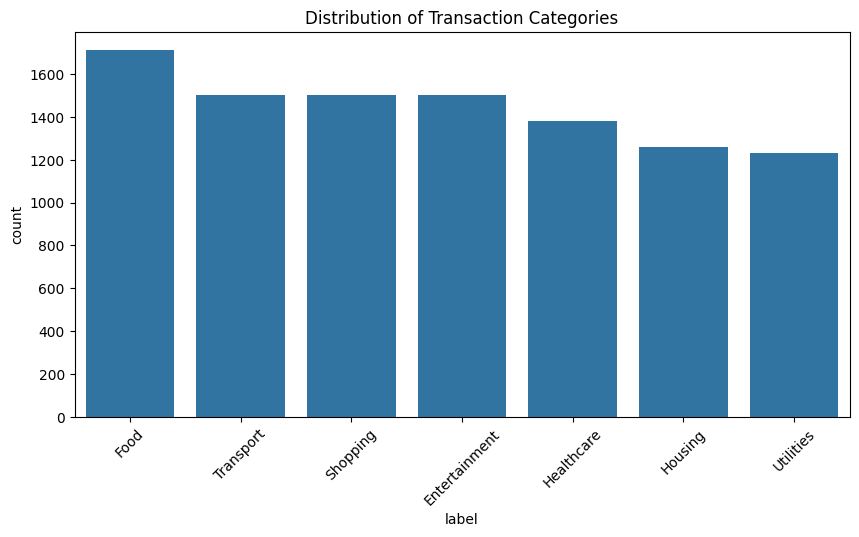

Total Records: 10170

Missing Labels Check:
text      0
label    90
dtype: int64

Found 60 records with completely empty text descriptions.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xticks(rotation=45)
plt.show()

print("Total Records:", len(df))
print("\nMissing Labels Check:")
print(df.isnull().sum())

# Check for empty string inputs
empty_strings = df[df['text'].str.strip() == '']
print(f"\nFound {len(empty_strings)} records with completely empty text descriptions.")

## 3. Data Cleaning Pipeline
We need to filter out the noise before feeding this into the model. Real users will sometimes skip the description or enter garbage data.

In [7]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove heavy special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# 1. Drop rows where the category (label) was completely missing
df_clean = df.dropna(subset=['label']).copy()

# 2. Clean the text
df_clean['text'] = df_clean['text'].apply(clean_text)

# 3. Drop rows where text became completely empty after cleaning (e.g., if user only typed "!!!")
df_clean = df_clean[df_clean['text'].str.strip() != '']

print(f"Data Cleaning Complete. We dropped {len(df) - len(df_clean)} bad records.")
print(f"Remaining clean records: {len(df_clean)}")

Data Cleaning Complete. We dropped 150 bad records.
Remaining clean records: 10020


## 2. Exploratory Data Analysis (EDA)
Let's look at the distribution of our categories and check for missing or corrupted data.

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10170 entries, 0 to 10169
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10170 non-null  str  
 1   label   10080 non-null  str  
dtypes: str(2)
memory usage: 159.0 KB
None

--- Missing Values ---
text      0
label    90
dtype: int64


/tmp/ipykernel_76083/173014856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


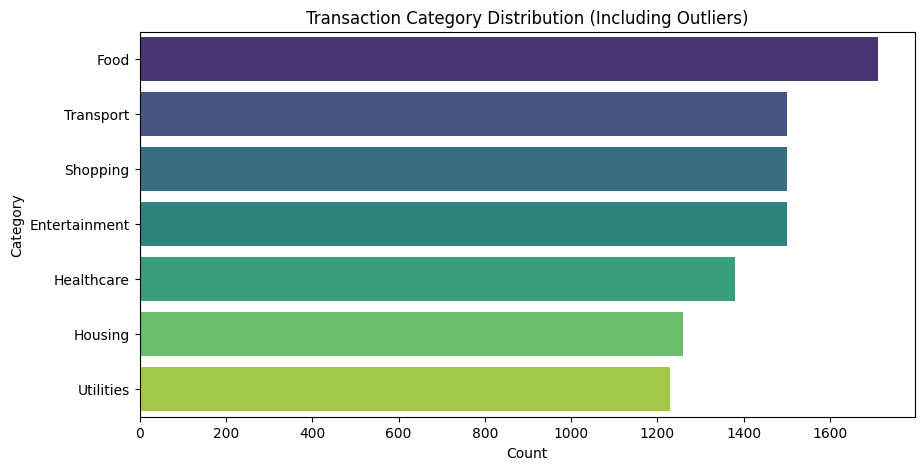

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Transaction Category Distribution (Including Outliers)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Ensure cleaned_text exists (run Data Cleaning cell first, or we create it here)
if 'cleaned_text' not in df.columns:
    import re
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))
    def clean_text(text):
        if pd.isna(text): return ""
        text = str(text).lower()
        text = re.sub(r'\d+[kK]?', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        words = text.split()
        filtered = [w for w in words if w not in stop_words]
        return " ".join(filtered)
    df = df.dropna().copy()
    df['cleaned_text'] = df['text'].apply(clean_text)
    df = df[df['cleaned_text'].str.strip() != ""]
    print("Applied cleaning (Data Cleaning cell was not run first).")

X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Applied cleaning (Data Cleaning cell was not run first).
Train size: 7968, Test size: 1992


## 3. Data Cleaning & Text Preprocessing
Before passing it to TF-IDF, we must:
1. Drop NaN values.
2. Remove punctuation and special characters.
3. Remove common English stopwords (e.g., "the", "and", "on", "for") so the model focuses strictly on core action words.
4. Strip numbers. The model shouldn't memorize prices (e.g., "spent 4k" -> "spent").

In [10]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Lowercase
    text = str(text).lower()
    
    # Remove prices/numbers (e.g., '1200', '4k', '500')
    text = re.sub(r'\d+[kK]?', '', text)
    
    # Remove special punctuation (keep letters only)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove STOP WORDS ('on', 'for', 'the')
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    
    return " ".join(filtered_words)

# 1. Drop NaNs
df = df.dropna().copy()

# 2. Apply cleaning function
df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Drop rows that became completely empty after cleaning 
# (e.g., someone just typed '1234' or '????')
df = df[df['cleaned_text'].str.strip() != ""]

print(f"Remaining rows after dropping pure junk/empty rows: {len(df)}")
display(df[['text', 'cleaned_text', 'label']].head(10))

Remaining rows after dropping pure junk/empty rows: 9960


,text,cleaned_text,label
0,spent 242 on mortgage,spent mortgage,Housing
1,395 for pharmacy,pharmacy,Healthcare
2,tolls,tolls,Transport
3,spent 58k on coffee,spent coffee,Food
4,spent 95 on laptop,spent laptop,Shopping
5,paid for clothes,paid clothes,Shopping
6,just paid 291 for clinic,paid clinic,Healthcare
7,electricity cost,electricity cost,Utilities
8,paid 388000 towards trash,paid towards trash,Utilities
9,paid for amazon,paid amazon,Shopping


## 4. Model Training (TF-IDF + Random Forest + GridSearchCV)
With the clean data, we convert text to numbers using TF-IDF and sweep hyperparameters to find the optimal Random Forest.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Make sure X_train, X_test, y_train, y_test are already defined above this cell

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
])

# Fine-tuning grid for Random Forest (regularization to avoid overfitting)
param_grid = {
    "tfidf__ngram_range": [(1, 2)],           # bigrams help with phrase-level features
    "tfidf__max_features": [10000, 15000, 20000],  # more features for 20 categories
    "clf__n_estimators": [100, 150],
    "clf__max_depth": [25, 30, 35],           # deeper trees for better separation
    "clf__min_samples_leaf": [1, 2],         # less regularization for better fit
}

print("Starting Grid Search for Random Forest (this might take a minute)...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extract the best performing pipeline
rf_pipeline = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

rf_preds = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("\nOptimized Random Forest Accuracy:", rf_acc)
print("\nClassification Report (Optimized Random Forest):\n", classification_report(y_test, rf_preds))

Starting Grid Search for Random Forest (this might take a minute)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits



Best Parameters Found: {'clf__max_depth': 35, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 150, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

Optimized Random Forest Accuracy: 0.9949799196787149

Classification Report (Optimized Random Forest):
                precision    recall  f1-score   support

Entertainment       1.00      0.99      0.99       300
         Food       0.98      1.00      0.99       330
   Healthcare       0.99      0.98      0.98       276
      Housing       1.00      1.00      1.00       252
     Shopping       1.00      1.00      1.00       294
    Transport       1.00      1.00      1.00       294
    Utilities       1.00      1.00      1.00       246

     accuracy                           0.99      1992
    macro avg       1.00      0.99      1.00      1992
 weighted avg       1.00      0.99      0.99      1992



## 5. Evaluation & Confusion Matrix
See exactly which categories confused the Random Forest.

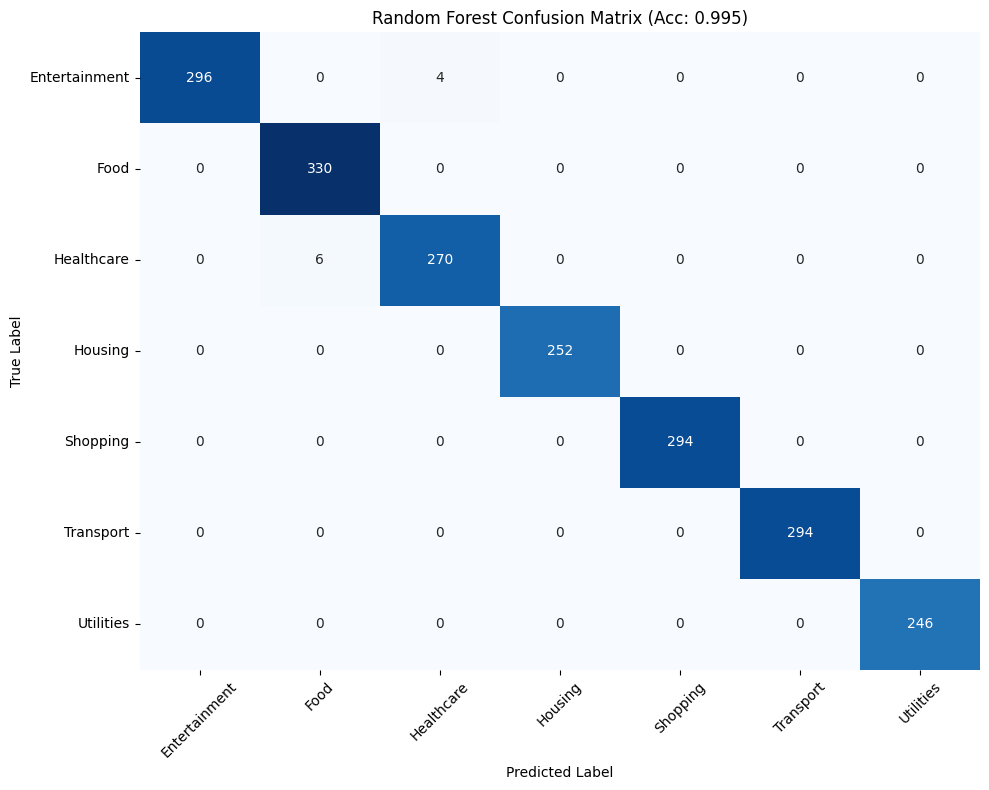

In [12]:
from sklearn.metrics import confusion_matrix

labels = sorted(df['label'].unique())

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, rf_preds, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=labels, yticklabels=labels)
ax.set_title(f"Random Forest Confusion Matrix (Acc: {rf_acc:.3f})")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 6. Real-World API Test (Simulation)
Testing random user inputs using the cleaning function and model prediction.

In [15]:
import numpy as np


def predict_transaction(text):
    cleaned = clean_text(text)
    if cleaned.strip() == "":
        return "Other/Unknown" # Default fallback for pure junk
    
    # Get probabilities to show confidence
    probs = rf_pipeline.predict_proba([cleaned])[0]
    max_prob = max(probs)
    pred_label = rf_pipeline.classes_[np.argmax(probs)]
    
    # If model is extremely uncertain (< 30%), label as Unknown
    if max_prob < 0.30:
        return f"Other/Unknown (Uncertain, highest was {pred_label} at {max_prob:.2f})"
        
    return f"{pred_label} (Confidence: {max_prob:.2f})"

test_inputs = [
    "spent 4k on snacks",
    "bought a huge TV at Best Buy for 1000",
    "ordered a large pepperoni pizza for lunch",
    "paid 1200 for rent and water",
    "monthly spotify premium",
    "uber ride back home",
    "rolex and chapati",
    "bought pain killers at pharmacy",
    "18273918237",                 # Pure noise test
    "transfer to john for lunch",    # Ambiguous test
    "cash withdrawal at atm",
    "bought medicine from the hospital at 5000"         # Untrained keyword test
]

print("=== REAL WORLD INFERENCE TEST ===\n")
for text in test_inputs:
    print(f"🔹 Input: \"{text}\"")
    print(f"   Prediction : {predict_transaction(text)}\n")

=== REAL WORLD INFERENCE TEST ===

🔹 Input: "spent 4k on snacks"
   Prediction : Food (Confidence: 0.32)

🔹 Input: "bought a huge TV at Best Buy for 1000"
   Prediction : Shopping (Confidence: 0.82)

🔹 Input: "ordered a large pepperoni pizza for lunch"
   Prediction : Food (Confidence: 0.41)

🔹 Input: "paid 1200 for rent and water"
   Prediction : Housing (Confidence: 0.56)

🔹 Input: "monthly spotify premium"
   Prediction : Entertainment (Confidence: 0.39)

🔹 Input: "uber ride back home"
   Prediction : Transport (Confidence: 0.39)

🔹 Input: "rolex and chapati"
   Prediction : Other/Unknown (Uncertain, highest was Food at 0.19)

🔹 Input: "bought pain killers at pharmacy"
   Prediction : Healthcare (Confidence: 0.46)

🔹 Input: "18273918237"
   Prediction : Other/Unknown

🔹 Input: "transfer to john for lunch"
   Prediction : Food (Confidence: 0.32)

🔹 Input: "cash withdrawal at atm"
   Prediction : Other/Unknown (Uncertain, highest was Food at 0.19)

🔹 Input: "bought medicine from the h

## 7. Export Model Component
Exporting the tuned `best_rf_pipeline` so it handles the TF-IDF transform and Model Prediction simultaneously.

In [16]:
import joblib
import os

joblib.dump(rf_pipeline, "./transaction_rf_pipeline.pkl")
print("Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl")

Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl
